<a href="https://colab.research.google.com/github/DOHA-BASEM3/FINAL-PROJECT/blob/main/Ghena_Preprocessing_PCA_tSNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
# Course: Machine Learning II
# # Anomaly Detection and Customer Segmentation Using Unsupervised Machine Learning and Deep Learning
# Team Members : Doha ,Ghena, Oraib
# Data set : Credit Card Fraud Detection Dataset

# **1: Data Preprocessing**

# Import Libraries

In [104]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Data Loading

In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Final_Project/creditcard.csv')

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Exploratory Data Analysis (EDA)

In [107]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [108]:
# Check for missing values in each feature
print(df.isnull().sum().sum())

0


In [109]:
#Check the duplicated records
print(df.duplicated().sum())

# Remove duplicated records to improve data quality
df=df.drop_duplicates()

# Reset dataframe indices after removing duplicates
df = df.reset_index(drop=True)


1081


In [110]:
df['Class'].value_counts()
# The dataset is highly imbalanced,
# where fraudulent transactions represent only 0.17% of the total observations.


,count
Class,
0,283253
1,473


In [111]:
fraud_percentage = (df['Class'].sum() / len(df)) * 100
print(f"Fraud Percentage: {fraud_percentage:.4f}%")

Fraud Percentage: 0.1667%


# Data Preprocessing

In [112]:
X = df.drop('Class', axis=1)
y = df['Class']

# Feature Scaling

In [113]:
# Scaling features before PCA and anomaly detection.
# RobustScaler is used to reduce outlier influence.


# Only Time and Amount were scaled,
# as the remaining features (V1–V28)
# were already transformed using PCA.

scaler = RobustScaler()
X_scaled = X.copy()

X_scaled[['Time', 'Amount']] = scaler.fit_transform(X_scaled[['Time', 'Amount']])

X_scaled[['Time', 'Amount']].describe()

,Time,Amount
count,283726.000000,283726.000000
mean,0.118912,0.924387
std,0.557988,3.482123
min,-0.995290,-0.305938
25%,-0.358286,-0.228063
50%,0.000000,0.000000
75%,0.641714,0.771937
max,1.035329,356.962314


In [114]:
# Verifying the final dataset dimensions
# after preprocessing.

print("Features Shape:", X_scaled.shape)
print("Target Shape:", y.shape)


Features Shape: (283726, 30)
Target Shape: (283726,)


## *The dataset is now cleaned, scaled, and ready for dimensionality reduction.*

# **2: Dimensionality Reduction with PCA**

##Apply PCA

In [115]:
# Applying PCA while preserving 95% of the dataset variance.

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

# Comparing the original and reduced dimensions.

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

print("\n",pca.explained_variance_ratio_)

print("\n", np.sum(pca.explained_variance_ratio_))

Original Shape: (283726, 30)
Reduced Shape: (283726, 22)

 [0.32689767 0.08604632 0.05634564 0.05229584 0.04650542 0.04198303
 0.03824846 0.03246825 0.02808536 0.02716703 0.02481647 0.02327759
 0.02308241 0.0212641  0.01976632 0.01888398 0.01780283 0.01662688
 0.01625591 0.01536074 0.01252552 0.01224194]

 0.9579476889030824


##  Variance Analysis Plot

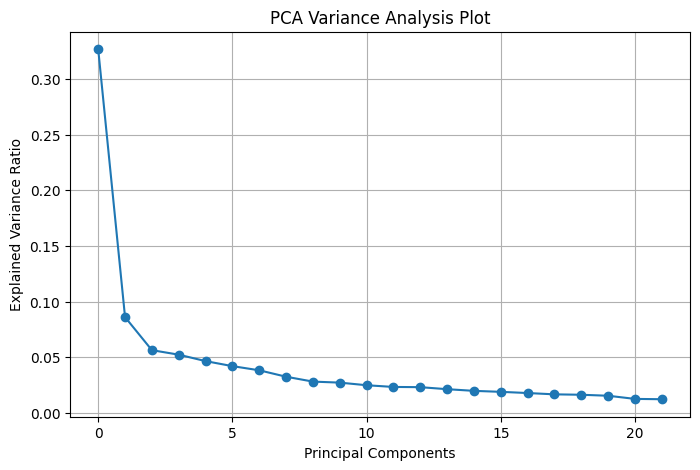

In [116]:
plt.figure(figsize=(8,5))

plt.plot(
    pca.explained_variance_ratio_,
    marker='o'
)

plt.title("PCA Variance Analysis Plot")

plt.xlabel("Principal Components")

plt.ylabel("Explained Variance Ratio")

plt.grid(True)

plt.show()

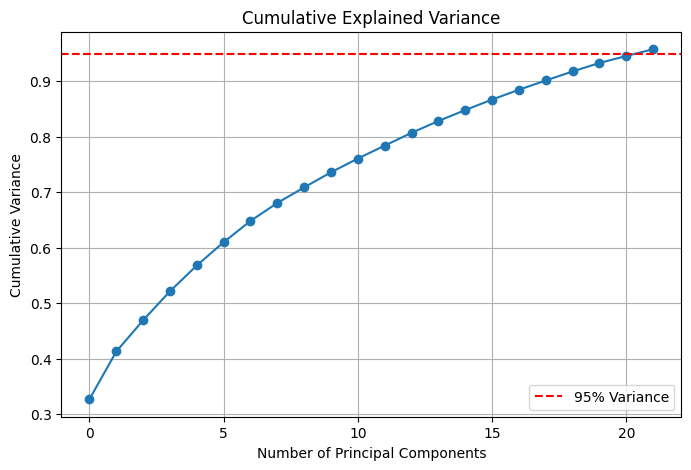

In [117]:
# Plotting cumulative variance to determine the number of principal components
# needed to preserve 95% variance.

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% Variance'
)

plt.title("Cumulative Explained Variance")

plt.xlabel("Number of Principal Components")

plt.ylabel("Cumulative Variance")

plt.grid(True)

plt.legend()

plt.show()

## PCA Visualization

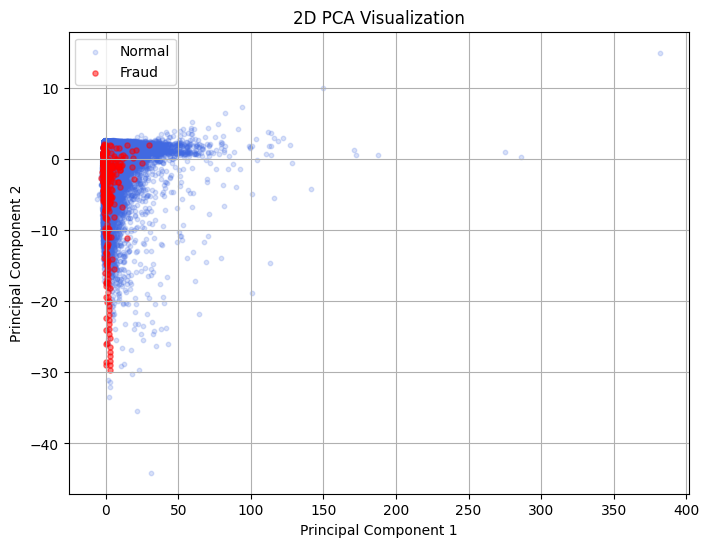

In [118]:
# Applying PCA for 2D visualization.

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

# Plotting the first two principal components.

plt.figure(figsize=(8,6))


plt.scatter(
    X_pca_2d[y == 0, 0],
    X_pca_2d[y == 0, 1],
    c='royalblue',
    alpha=0.2,
    s=10,
    label='Normal'
)

plt.scatter(
    X_pca_2d[y == 1, 0],
    X_pca_2d[y == 1, 1],
    c='red',
    alpha=0.5,
    s=14,
    label='Fraud'
)
plt.title("2D PCA Visualization")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)
plt.legend()
plt.show()

# **3: Data Visualization with t-SNE**

##Apply t-SNE

In [119]:
# Applying t-SNE on a sampled subset for visualization.

sample_df = df.sample(n=5000, random_state=42)

X_sample = X_pca[sample_df.index]
y_sample = sample_df['Class']


tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_sample)

## 2D t-SNE Visualization

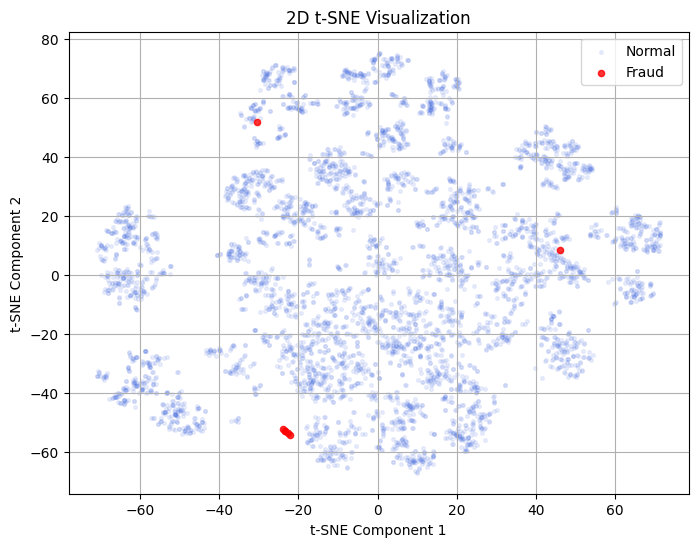

In [120]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[y_sample == 0, 0],
    X_tsne[y_sample == 0, 1],
    c='royalblue',
    alpha=0.10,
    s=7,
    label='Normal'
)

plt.scatter(
    X_tsne[y_sample == 1, 0],
    X_tsne[y_sample == 1, 1],
    c='red',
    alpha=0.8,
    s=20,
    label='Fraud'
)

plt.title("2D t-SNE Visualization")

plt.xlabel("t-SNE Component 1")

plt.ylabel("t-SNE Component 2")

plt.grid(True)
plt.legend()
plt.show()

In [121]:

import numpy as np
np.save('/content/drive/MyDrive/ML_Final_Project/X_scaled.npy', X.values)
np.save('/content/drive/MyDrive/ML_Final_Project/y.npy', y.values)
np.save('/content/drive/MyDrive/ML_Final_Project/X_pca.npy', X_pca)
print('✅ Saved for team!')

✅ Saved for team!




---



# **4: Clustering with DBSCAN**

## Apply DBSCAN

In [122]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [123]:
# Testing multiple DBSCAN parameter combinations
# to identify the most balanced clustering behavior
# using a sampled subset for efficiency.
sample_size = 10000
np.random.seed(42)

idx = np.random.choice(len(X_pca), sample_size, replace=False)
X_sample = X_pca[idx]

eps_values = [2.7, 2.8, 2.9, 3.0, 3.1, 3.2]
min_samples_values = [5,10,15]
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_sample)

        n_noise = np.sum(labels == -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_percentage = (n_noise / len(labels)) * 100

        # Metrics are only valid when more than one cluster exists
        if n_clusters > 1:
            silhouette = silhouette_score(X_sample, labels)
            davies_bouldin = davies_bouldin_score(X_sample, labels)
        else:
            silhouette = np.nan
            davies_bouldin = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "noise_percentage": round(noise_percentage, 2),
            "silhouette_score": round(silhouette, 4) if not np.isnan(silhouette) else np.nan,

        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="silhouette_score",
    ascending=False
)
results_df

,eps,min_samples,clusters,noise_points,noise_percentage,silhouette_score
17,3.2,15,2,1457,14.57,0.0848
14,3.1,15,2,1620,16.20,0.0799
10,3.0,10,2,1621,16.21,0.0794
11,3.0,15,2,1775,17.75,0.0779
7,2.9,10,5,1783,17.83,0.0739
16,3.2,10,3,1339,13.39,0.0721
8,2.9,15,5,2003,20.03,0.0676
13,3.1,10,3,1488,14.88,0.0669
4,2.8,10,6,1985,19.85,0.0643
5,2.8,15,5,2230,22.30,0.0597


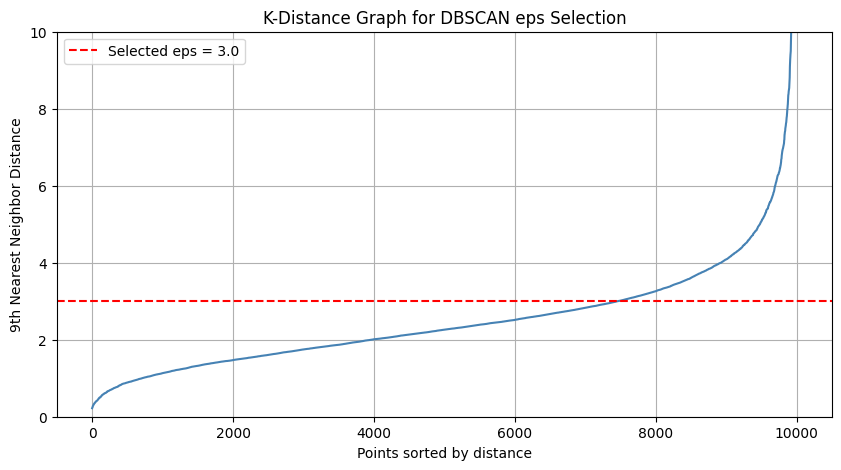

In [124]:
# Using K-distance graph to estimate a suitable eps value
# based on nearest neighbor distances
# (eps=3.0, min_samples=10)
nbrs = NearestNeighbors(n_neighbors=10).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)

distances = np.sort(distances[:, 9])

plt.figure(figsize=(10,5))
plt.plot(distances, color='steelblue')

plt.axhline(y=3.0, color='red', linestyle='--', label='Selected eps = 3.0')
#plt.axhline(y=2.9, color='green', linestyle='--', label='Compared eps = 2.9')
#plt.axhline(y=3.1, color='orange', linestyle='--', label='Compared eps = 3.1')

# Limit y-axis for better elbow visualization
plt.ylim(0, 10)

plt.title('K-Distance Graph for DBSCAN eps Selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('9th Nearest Neighbor Distance')
plt.legend()
plt.grid(True)
plt.show()

In [127]:
# Final DBSCAN sample
final_sample_size = 30000
np.random.seed(42)

final_idx = np.random.choice(len(X_pca), final_sample_size, replace=False)

X_pca_final = X_pca[final_idx]
X_scaled_final = X_scaled.iloc[final_idx] if hasattr(X_scaled, "iloc") else X_scaled[final_idx]
y_final = y.iloc[final_idx] if hasattr(y, "iloc") else y[final_idx]

print("PCA final sample shape:", X_pca_final.shape)
print("Scaled final sample shape:", X_scaled_final.shape)

PCA final sample shape: (30000, 22)
Scaled final sample shape: (30000, 30)


In [132]:
# Apply DBSCAN without PCA
best_eps = 3.0
best_min_samples = 10

dbscan_scaled = DBSCAN(eps=best_eps, min_samples=best_min_samples)

labels_scaled = dbscan_scaled.fit_predict(X_scaled_final)

n_clusters_scaled = len(set(labels_scaled)) - (1 if -1 in labels_scaled else 0)
n_noise_scaled = np.sum(labels_scaled == -1)
noise_percentage_scaled = (n_noise_scaled / len(labels_scaled)) * 100

if n_clusters_scaled > 1:
    silhouette_scaled = silhouette_score(X_scaled_final, labels_scaled)
else:
    silhouette_scaled = np.nan

print("DBSCAN without PCA")
print("-------------------")
print("Clusters:", n_clusters_scaled)
print("Noise points:", n_noise_scaled)
print("Noise percentage:", round(noise_percentage_scaled, 2), "%")
print("Silhouette score:", round(silhouette_scaled, 4))

DBSCAN without PCA
-------------------
Clusters: 8
Noise points: 4475
Noise percentage: 14.92 %
Silhouette score: 0.0274


In [128]:
# Apply DBSCAN with PCA

dbscan_pca = DBSCAN(eps=best_eps, min_samples=best_min_samples)

labels_pca = dbscan_pca.fit_predict(X_pca_final)

n_clusters_pca = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
n_noise_pca = np.sum(labels_pca == -1)
noise_percentage_pca = (n_noise_pca / len(labels_pca)) * 100

if n_clusters_pca > 1:
    silhouette_pca = silhouette_score(X_pca_final, labels_pca)
else:
    silhouette_pca = np.nan

print("DBSCAN with PCA")
print("----------------")
print("Clusters:", n_clusters_pca)
print("Noise points:", n_noise_pca)
print("Noise percentage:", round(noise_percentage_pca, 2), "%")
print("Silhouette score:", round(silhouette_pca, 4))

DBSCAN with PCA
----------------
Clusters: 8
Noise points: 3339
Noise percentage: 11.13 %
Silhouette score: -0.0052


## Cluster Visualization

In [ ]:
# Visualizing DBSCAN clustering results
# with different colors for clusters and red for noise points
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 7))
unique_labels = np.unique(best_labels)
for label in unique_labels:

    # Noise points
    if label == -1:
        color = 'red'
        label_name = 'Noise'
    else:
        color = plt.cm.tab20(label % 20)
        label_name = f'Cluster {label}'
    plt.scatter(
        X_sample[best_labels == label, 0],
        X_sample[best_labels == label, 1],
        c=[color],
        s=10,
        alpha=0.6,
        label=label_name )
plt.title("DBSCAN Clustering on PCA-Transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend(loc='best', fontsize=8)
plt.grid(True)

plt.show()

In [ ]:
# Comparing DBSCAN performance before and after PCA
# to evaluate the effect of dimensionality reduction
X_scaled_sample = np.asarray(X_scaled[:10000])
X_pca_sample = np.asarray(X_sample)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Without PCA
for label in np.unique(labels_scaled):
    mask = labels_scaled == label
    color = 'red' if label == -1 else plt.cm.tab20(label % 20)

    axes[0].scatter(
        X_scaled_sample[mask, 0],
        X_scaled_sample[mask, 1],
        c=[color],
        s=10,
        alpha=0.6
    )
axes[0].set_title("DBSCAN Without PCA")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# With PCA
for label in np.unique(best_labels):
    mask = best_labels == label
    color = 'red' if label == -1 else plt.cm.tab20(label % 20)
    axes[1].scatter(
        X_pca_sample[mask, 0],
        X_pca_sample[mask, 1],
        c=[color],
        s=10,
        alpha=0.6 )
axes[1].set_title("DBSCAN With PCA")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
axes[1].grid(True)
plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
# Evaluating clustering quality using

# Remove noise points
mask = best_labels != -1

# Evaluation metrics without noise
# Silhouette Score

silhouette = silhouette_score(
    X_sample[mask],
    best_labels[mask]
)

# Davies-Bouldin Index
db_index = davies_bouldin_score(
    X_sample[mask],
    best_labels[mask]
)

print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", db_index)

**Cluster Distribution**

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    cluster_distribution.index.astype(str),
    cluster_distribution.values
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Points")

plt.yscale('log')

plt.grid(axis='y')

plt.show()

### The cluster distribution shows that most observations belong to the main dense cluster, while smaller clusters and noise points represent less frequent behavioral patterns and potential anomalies.

# **5: Anomaly Detection Using One-Class SVM**

## Train One-Class SVM

In [ ]:
# Import required libraries
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


In [ ]:
# One-Class SVM is computationally expensive,
# so we use PCA-transformed data and a stratified sample.

sample_size = 30000
np.random.seed(42)

sample_idx = np.random.choice(len(X_pca), sample_size, replace=False)

X_ocsvm = X_pca[sample_idx]
y_ocsvm = y.iloc[sample_idx].values

In [ ]:
# Split the data for evaluation.
# The model will be trained only on normal transactions.

X_train, X_test, y_train, y_test = train_test_split(
    X_ocsvm,
    y_ocsvm,
    test_size=0.30,
    random_state=42,
    stratify=y_ocsvm
)

# Keep only normal transactions for training
X_train_normal = X_train[y_train == 0]

print("Training normal samples:", X_train_normal.shape)
print("Testing samples:", X_test.shape)
print("Fraud cases in test:", np.sum(y_test == 1))

In [ ]:
# Train One-Class SVM
# nu controls the expected proportion of anomalies.
# Since fraud is rare, we use a small value.

ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.01
)

ocsvm.fit(X_train_normal)

## Predict Anomalies

In [ ]:
# Prediction output:
#  1  = normal
# -1  = anomaly

y_pred_raw = ocsvm.predict(X_test)

# Convert predictions to binary format:
# 0 = normal
# 1 = anomaly/fraud

y_pred = np.where(y_pred_raw == -1, 1, 0)

print("Detected anomalies:", np.sum(y_pred == 1))
print("Actual fraud cases:", np.sum(y_test == 1))

## Performance Analysis

**Recall**  & **F1-Score**

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Fraud"]
))

###Precision

In [ ]:
# Decision function gives anomaly scores.
# Lower scores mean the point is more abnormal.

scores = ocsvm.decision_function(X_test)

# For ROC-AUC, fraud should have higher anomaly score,
# so we multiply by -1.

anomaly_scores = -scores

roc_auc = roc_auc_score(y_test, anomaly_scores)

print("ROC-AUC Score:", round(roc_auc, 4))

**ROC-AUC Curve**

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve - One-Class SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)
plt.show()

# Visualization

In [ ]:
# Visualize One-Class SVM results using first two PCA components

plt.figure(figsize=(8,6))

plt.scatter(
    X_test[y_pred == 0, 0],
    X_test[y_pred == 0, 1],
    s=8,
    alpha=0.3,
    label="Predicted Normal"
)

plt.scatter(
    X_test[y_pred == 1, 0],
    X_test[y_pred == 1, 1],
    s=20,
    alpha=0.8,
    label="Predicted Anomaly"
)

plt.title("One-Class SVM Anomaly Detection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()
plt.grid(True)
plt.show()

# **6: Deep Learning with TensorFlow and Keras**

##Prepare Data

## Build Autoencoder Architecture

## Train the Model

##Loss Curves

##Reconstruction Error

## Learned Latent Representations

# Model Evaluation

# **Loss**

# **Accuracy**

# **Reconstruction Error**